<h1 style="color:#56B4E9;">Week 6 — Day 5</h1>

<h2 style="color:#0072B2;">Neural Network Tuning, Evaluation and Sprint Review</h2>

<h3>ECG-Based Multi-Label Cardiac Diagnosis Using PTB-XL</h3>

Day 4 produced a complete Keras workflow for predicting four cardiac disease classes: MI, STTC, CD, and HYP.

The basic neural network learned useful patterns and achieved high precision, but its Macro Recall remained low. At a threshold of 0.5, the network missed many true disease cases and did not outperform the Logistic Regression baseline according to the project's recall priority.

Day 5 will improve the network systematically. Only one hyperparameter will be changed at a time so that the effect of each change can be measured clearly.

EarlyStopping will stop training when validation loss no longer improves, while ModelCheckpoint will preserve the best model observed during training.

All model and threshold decisions will be made using the validation set. The test set will remain untouched until the final configuration has been selected.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Tune a neural network systematically by changing one variable at a time.
- Use EarlyStopping to stop training when validation performance stops improving.
- Use ModelCheckpoint to preserve the best model during training.
- Compare learning rates, network sizes, dropout rates, and batch sizes.
- Record every experiment in a consistent metric table.
- Evaluate multi-label predictions using Precision, Recall, and F1-score.
- Improve disease recall by selecting thresholds using validation data only.
- Compare the tuned neural network fairly with the Day 1 baseline.
- Assemble the final Sprint 1 evidence.
- Complete the Sprint Review and Retrospective.

<h2 style="color:#0072B2;">1. The Problem Carried Forward from Day 4</h2>

The Day 4 basic neural network used the following configuration:

- Architecture: 72 → 32 → 16 → 4
- Hidden activation: ReLU
- Output activation: Sigmoid
- Optimizer: Adam
- Learning rate: 0.001
- Batch size: 32
- Dropout: 0.0
- Training epochs: 40
- Prediction threshold: 0.5

The model achieved a Test Macro Precision of 0.6717, but its Test Macro Recall was only 0.3751.

This means that when the neural network predicted a disease, its prediction was often correct. However, it failed to detect a large proportion of the patients who actually had one of the target diseases.

The Logistic Regression baseline achieved a much higher Test Macro Recall of 0.6642.

Therefore, the main Day 5 objective is:

> Improve the neural network's disease detection ability without using the test set during model selection.

The tuning process will change one hyperparameter at a time. This allows each performance difference to be connected to one specific configuration change.

In [1]:
from pathlib import Path
import ast
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import tensorflow as tf

from sklearn.preprocessing import StandardScaler


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


DATA_DIR = Path(
    "../../cardiac-patient-monitoring/data/raw/ptb-xl"
)

metadata_path = DATA_DIR / "ptbxl_database.csv"
statements_path = DATA_DIR / "scp_statements.csv"


metadata = pd.read_csv(
    metadata_path,
    index_col="ecg_id"
)

scp_statements = pd.read_csv(
    statements_path,
    index_col=0
)


metadata["scp_codes_dict"] = metadata[
    "scp_codes"
].apply(ast.literal_eval)


def get_diagnostic_classes(
    scp_codes_dictionary
):
    diagnostic_classes = set()

    for diagnostic_code in scp_codes_dictionary:
        if diagnostic_code not in scp_statements.index:
            continue

        statement = scp_statements.loc[
            diagnostic_code
        ]

        if not bool(statement["diagnostic"]):
            continue

        diagnostic_class = statement[
            "diagnostic_class"
        ]

        if pd.notna(diagnostic_class):
            diagnostic_classes.add(
                diagnostic_class
            )

    return diagnostic_classes


available_ids = []

for ecg_id, row in metadata.iterrows():
    record_path = (
        DATA_DIR / row["filename_lr"]
    )

    dat_exists = (
        record_path.with_suffix(".dat").exists()
    )

    hea_exists = (
        record_path.with_suffix(".hea").exists()
    )

    if dat_exists and hea_exists:
        available_ids.append(ecg_id)


available_metadata = metadata.loc[
    available_ids
].copy()


available_metadata["diagnostic_classes"] = (
    available_metadata["scp_codes_dict"].apply(
        get_diagnostic_classes
    )
)


selection_classes = [
    "NORM",
    "MI",
    "STTC",
    "CD",
    "HYP"
]

target_classes = [
    "MI",
    "STTC",
    "CD",
    "HYP"
]


for class_name in selection_classes:
    available_metadata[class_name] = (
        available_metadata[
            "diagnostic_classes"
        ].apply(
            lambda classes: int(
                class_name in classes
            )
        )
    )


model_data = available_metadata[
    available_metadata[
        selection_classes
    ].sum(axis=1) > 0
].copy()


feature_rows = []

for ecg_id, row in model_data.iterrows():
    signal, information = wfdb.rdsamp(
        str(
            DATA_DIR
            / row["filename_lr"]
        )
    )

    features = {
        "ecg_id": ecg_id
    }

    for lead_index, lead_name in enumerate(
        information["sig_name"]
    ):
        lead = signal[:, lead_index]

        lead_minimum = np.min(lead)
        lead_maximum = np.max(lead)

        features[
            f"{lead_name}_mean"
        ] = np.mean(lead)

        features[
            f"{lead_name}_std"
        ] = np.std(lead)

        features[
            f"{lead_name}_min"
        ] = lead_minimum

        features[
            f"{lead_name}_max"
        ] = lead_maximum

        features[
            f"{lead_name}_range"
        ] = (
            lead_maximum
            - lead_minimum
        )

        features[
            f"{lead_name}_rms"
        ] = np.sqrt(
            np.mean(lead ** 2)
        )

    feature_rows.append(features)


X = pd.DataFrame(
    feature_rows
).set_index("ecg_id")


y = model_data.loc[
    X.index,
    target_classes
].astype("float32")


train_ids = model_data[
    model_data["strat_fold"].between(
        1,
        8
    )
].index

validation_ids = model_data[
    model_data["strat_fold"] == 9
].index

test_ids = model_data[
    model_data["strat_fold"] == 10
].index


X_train = X.loc[
    X.index.intersection(train_ids)
]

X_validation = X.loc[
    X.index.intersection(validation_ids)
]

X_test = X.loc[
    X.index.intersection(test_ids)
]


y_train = y.loc[X_train.index]

y_validation = y.loc[
    X_validation.index
]

y_test = y.loc[X_test.index]


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
).astype("float32")

X_validation_scaled = scaler.transform(
    X_validation
).astype("float32")

X_test_scaled = scaler.transform(
    X_test
).astype("float32")


y_train_array = y_train.to_numpy(
    dtype="float32"
)

y_validation_array = (
    y_validation.to_numpy(
        dtype="float32"
    )
)

y_test_array = y_test.to_numpy(
    dtype="float32"
)


print("TensorFlow version:", tf.__version__)
print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU")
)

print(
    "\nTotal ECGs in metadata:",
    len(metadata)
)

print(
    "Complete ECG recordings:",
    len(available_metadata)
)

print(
    "ECGs used for modeling:",
    len(model_data)
)

print(
    "Number of features:",
    X.shape[1]
)

print(
    "\nTraining:",
    X_train_scaled.shape,
    y_train_array.shape
)

print(
    "Validation:",
    X_validation_scaled.shape,
    y_validation_array.shape
)

print(
    "Test:",
    X_test_scaled.shape,
    y_test_array.shape
)

print("\nTraining label counts:")
print(
    y_train.sum().astype(int)
)

print(
    "\nTraining rows with four zero disease labels:",
    int(
        (
            y_train.sum(axis=1) == 0
        ).sum()
    )
)

print(
    "Missing or infinite input values:",
    int(
        np.size(X_train_scaled)
        - np.isfinite(
            X_train_scaled
        ).sum()
    )
)

I0000 00:00:1787850173.999792   16579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787850174.001704   16579 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787850174.820929   16579 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787850177.135018   16579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
GPU devices: []

Total ECGs in metadata: 21799
Complete ECG recordings: 21799
ECGs used for modeling: 21388
Number of features: 72

Training: (17084, 72) (17084, 4)
Validation: (2146, 72) (2146, 4)
Test: (2158, 72) (2158, 4)

Training label counts:
MI      4379
STTC    4186
CD      3907
HYP     2119
dtype: int64

Training rows with four zero disease labels: 7243
Missing or infinite input values: 0


E0000 00:00:1787850315.212938   16579 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<h2 style="color:#0072B2;">2. EarlyStopping and ModelCheckpoint</h2>

Training for a fixed number of epochs does not guarantee that the final epoch contains the best model.

During Day 4, the basic network reached its best validation loss at epoch 29. Training continued until epoch 40, even though validation performance had already started to deteriorate.

Two Keras callbacks will solve this problem:

- `EarlyStopping` monitors validation loss and stops training when improvement has stopped.
- `ModelCheckpoint` saves the model whenever a new best validation loss is reached.

EarlyStopping will use:

- `monitor="val_loss"` because model selection must depend on unseen validation data.
- `mode="min"` because a smaller loss is better.
- `patience=8` to allow temporary fluctuations before stopping.
- `restore_best_weights=True` to return the model to its best-performing epoch.

ModelCheckpoint provides a permanent copy of the best complete model, including its architecture and learned weights.

In [2]:
from pathlib import Path

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    precision_recall_fscore_support
)

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MAX_EPOCHS = 100
PATIENCE = 8

print("Checkpoint directory:", CHECKPOINT_DIR.resolve())

Checkpoint directory: /home/haitham/binx-ai-ml-internship/week6/day5/checkpoints


<h2 style="color:#0072B2;">3. A Controlled Experiment System</h2>

A fair tuning experiment requires all configurations to follow the same training and evaluation process.

The following model-building function allows the network configuration to change while preserving the same:

- Input features.
- Four sigmoid outputs.
- Binary Cross-Entropy loss.
- Adam optimizer.
- Training and validation sets.
- Random seed.

The configurable values are:

- Hidden-layer sizes.
- Learning rate.
- Dropout rate.

Batch size will be controlled during training.

Changing only one value between two experiments allows the resulting performance difference to be attributed to that value.

In [3]:
def build_tuned_model(
    hidden_units=(32, 16),
    learning_rate=0.001,
    dropout_rate=0.0
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        )
    ])

    for units in hidden_units:
        model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu"
            )
        )

        if dropout_rate > 0:
            model.add(
                tf.keras.layers.Dropout(
                    dropout_rate
                )
            )

    model.add(
        tf.keras.layers.Dense(
            len(target_classes),
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="binary_accuracy"
            )
        ]
    )

    return model

In [4]:
def calculate_macro_metrics(
    y_true,
    probabilities,
    threshold=0.5
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    return {
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }

<h3 style="color:#009E73;">Running and Recording Each Experiment</h3>

Every experiment will:

1. Build a new network from the same random seed.
2. create independent EarlyStopping and ModelCheckpoint callbacks.
3. Train using the same training and validation sets.
4. Stop automatically when validation loss stops improving.
5. Restore and save the best model.
6. Predict validation probabilities.
7. Calculate Macro Precision, Recall, and F1-score.
8. Store the complete configuration and results.

The test set is deliberately excluded from this process.

In [5]:
experiment_results = []
experiment_histories = {}
experiment_models = {}
experiment_probabilities = {}


def run_experiment(
    experiment_name,
    hidden_units=(32, 16),
    learning_rate=0.001,
    dropout_rate=0.0,
    batch_size=32
):
    print("=" * 60)
    print("Experiment:", experiment_name)
    print("Hidden units:", hidden_units)
    print("Learning rate:", learning_rate)
    print("Dropout rate:", dropout_rate)
    print("Batch size:", batch_size)
    print("=" * 60)

    model = build_tuned_model(
        hidden_units=hidden_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}.keras"
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    model_checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=0
    )

    history = model.fit(
        X_train_scaled,
        y_train_array,
        validation_data=(
            X_validation_scaled,
            y_validation_array
        ),
        epochs=MAX_EPOCHS,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            model_checkpoint
        ],
        verbose=1
    )

    validation_probabilities = model.predict(
        X_validation_scaled,
        verbose=0
    )

    metrics = calculate_macro_metrics(
        y_validation_array,
        validation_probabilities,
        threshold=0.5
    )

    best_epoch = (
        np.argmin(
            history.history["val_loss"]
        ) + 1
    )

    best_validation_loss = np.min(
        history.history["val_loss"]
    )

    result = {
        "Experiment": experiment_name,
        "Hidden Units": str(hidden_units),
        "Learning Rate": learning_rate,
        "Dropout": dropout_rate,
        "Batch Size": batch_size,
        "Epochs Trained": len(
            history.history["loss"]
        ),
        "Best Epoch": best_epoch,
        "Best Validation Loss": best_validation_loss,
        **metrics
    }

    experiment_results.append(result)
    experiment_histories[experiment_name] = history
    experiment_models[experiment_name] = model
    experiment_probabilities[
        experiment_name
    ] = validation_probabilities

    print("\nExperiment completed.")
    print("Epochs trained:", result["Epochs Trained"])
    print("Best epoch:", best_epoch)
    print(
        "Best validation loss:",
        round(best_validation_loss, 4)
    )
    print(
        "Macro Recall:",
        round(metrics["Macro Recall"], 4)
    )
    print(
        "Macro F1:",
        round(metrics["Macro F1"], 4)
    )

    return model, history

<h2 style="color:#0072B2;">4. Reference Experiment with Callbacks</h2>

The first Day 5 experiment retains the Day 4 basic-network configuration:

- Hidden layers: 32 and 16 neurons.
- Learning rate: 0.001.
- Dropout: 0.0.
- Batch size: 32.
- Threshold: 0.5.

The only training-process change is the addition of EarlyStopping and ModelCheckpoint.

This experiment establishes the reference against which every tuning experiment will be compared.

In [6]:
reference_model, reference_history = (
    run_experiment(
        experiment_name="reference",
        hidden_units=(32, 16),
        learning_rate=0.001,
        dropout_rate=0.0,
        batch_size=32
    )
)

Experiment: reference
Hidden units: (32, 16)
Learning rate: 0.001
Dropout rate: 0.0
Batch size: 32
Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.7879 - loss: 0.4656 - val_binary_accuracy: 0.8164 - val_loss: 0.4315
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8212 - loss: 0.4107 - val_binary_accuracy: 0.8234 - val_loss: 0.4235
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8268 - loss: 0.4005 - val_binary_accuracy: 0.8242 - val_loss: 0.4177
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy: 0.8302 - loss: 0.3942 - val_binary_accuracy: 0.8250 - val_loss: 0.4138
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8323 - loss: 0.3886 - val_binary_accuracy: 0.8248 - val_loss: 0.4091
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8343 - loss: 0.3843 - val_binary_accuracy: 0.8260 - val_loss: 0.4071
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s

In [7]:
results_table = pd.DataFrame(
    experiment_results
)

display(
    results_table.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
0,reference,"(32, 16)",0.001,0.0,32,17,9,0.3987,0.6886,0.3638,0.4713


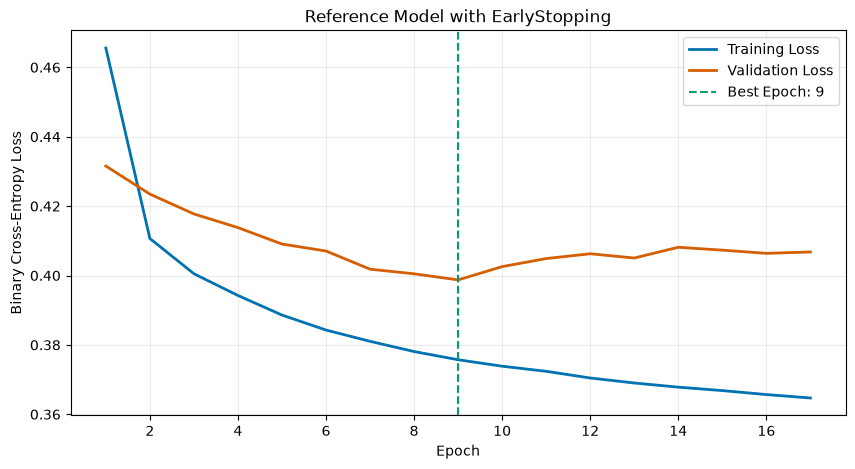

In [8]:
reference_epochs = range(
    1,
    len(reference_history.history["loss"]) + 1
)

reference_best_epoch = (
    np.argmin(
        reference_history.history["val_loss"]
    ) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    reference_epochs,
    reference_history.history["loss"],
    label="Training Loss",
    color="#0072B2",
    linewidth=2
)

plt.plot(
    reference_epochs,
    reference_history.history["val_loss"],
    label="Validation Loss",
    color="#D55E00",
    linewidth=2
)

plt.axvline(
    reference_best_epoch,
    color="#009E73",
    linestyle="--",
    label=f"Best Epoch: {reference_best_epoch}"
)

plt.title(
    "Reference Model with EarlyStopping"
)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

<h3 style="color:#D55E00;">Reference Experiment Diagnosis</h3>

The reference model reached its best validation loss of `0.3987` at epoch `9`.

Training continued until epoch `17`, because EarlyStopping allowed eight consecutive epochs without improvement. Once the patience limit was reached, training stopped and the weights from epoch 9 were restored.

Therefore, the model trained for only 17 of the allowed 100 epochs. This avoided 83 unnecessary epochs and prevented the final model from retaining the poorer weights produced after validation loss started increasing.

At the fixed threshold of `0.5`, the reference model achieved:

- Macro Precision: `0.6886`
- Macro Recall: `0.3638`
- Macro F1-score: `0.4713`

The model remained precise but continued to miss many true disease labels. EarlyStopping improved training efficiency and preserved the best validation-loss state, but it did not directly solve the low-recall problem.

The next experiments will change only the learning rate while preserving the same architecture, dropout rate, batch size, callbacks, and prediction threshold.

In [9]:
reference_checkpoint = (
    CHECKPOINT_DIR / "reference.keras"
)

print(
    "Reference checkpoint exists:",
    reference_checkpoint.exists()
)

print(
    "Checkpoint size:",
    round(
        reference_checkpoint.stat().st_size
        / 1024,
        2
    ),
    "KB"
)

Reference checkpoint exists: True
Checkpoint size: 59.56 KB


<h2 style="color:#0072B2;">5. Learning Rate Tuning</h2>

The learning rate controls the size of each parameter update performed by Adam.

The reference learning rate is `0.001`. Two additional values will be tested:

- `0.0005`: smaller updates that may produce slower but more stable learning.
- `0.002`: larger updates that may learn faster but could move past useful solutions.

Only the learning rate will change. All experiments will retain:

- Hidden layers: 32 and 16 neurons.
- Dropout rate: 0.0.
- Batch size: 32.
- Maximum epochs: 100.
- EarlyStopping patience: 8.
- Prediction threshold: 0.5.

This isolates the effect of the learning rate on validation performance.

In [10]:
low_lr_model, low_lr_history = (
    run_experiment(
        experiment_name="learning_rate_0005",
        hidden_units=(32, 16),
        learning_rate=0.0005,
        dropout_rate=0.0,
        batch_size=32
    )
)

Experiment: learning_rate_0005
Hidden units: (32, 16)
Learning rate: 0.0005
Dropout rate: 0.0
Batch size: 32
Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7627 - loss: 0.5017 - val_binary_accuracy: 0.8059 - val_loss: 0.4423
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8141 - loss: 0.4246 - val_binary_accuracy: 0.8175 - val_loss: 0.4303
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8211 - loss: 0.4113 - val_binary_accuracy: 0.8215 - val_loss: 0.4240
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8246 - loss: 0.4039 - val_binary_accuracy: 0.8230 - val_loss: 0.4197
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8273 - loss: 0.3988 - val_binary_accuracy: 0.8228 - val_loss: 0.4161
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8292 - loss: 0.3947 - val_binary_accuracy: 0.8240 - val_loss: 0.4134
Epoch 7/100
534/534 ━━━━━━━━━━━━━

In [11]:
high_lr_model, high_lr_history = (
    run_experiment(
        experiment_name="learning_rate_002",
        hidden_units=(32, 16),
        learning_rate=0.002,
        dropout_rate=0.0,
        batch_size=32
    )
)

Experiment: learning_rate_002
Hidden units: (32, 16)
Learning rate: 0.002
Dropout rate: 0.0
Batch size: 32


Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8039 - loss: 0.4426 - val_binary_accuracy: 0.8195 - val_loss: 0.4280
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8265 - loss: 0.4020 - val_binary_accuracy: 0.8237 - val_loss: 0.4187
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8312 - loss: 0.3922 - val_binary_accuracy: 0.8263 - val_loss: 0.4114
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8337 - loss: 0.3852 - val_binary_accuracy: 0.8274 - val_loss: 0.4050
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8354 - loss: 0.3808 - val_binary_accuracy: 0.8297 - val_loss: 0.4072
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8364 - loss: 0.3779 - val_binary_accuracy: 0.8291 - val_loss: 0.4017
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8378 - loss: 0.3743 - val_binary_accuracy: 0.8295 - val_loss: 0.4020

In [12]:
results_table = pd.DataFrame(
    experiment_results
)

learning_rate_results = results_table[
    results_table["Experiment"].isin([
        "reference",
        "learning_rate_0005",
        "learning_rate_002"
    ])
].copy()

display(
    learning_rate_results.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
0,reference,"(32, 16)",0.0010,0.0,32,17,9,0.3987,0.6886,0.3638,0.4713
1,learning_rate_0005,"(32, 16)",0.0005,0.0,32,32,24,0.3968,0.6793,0.3875,0.4912
2,learning_rate_002,"(32, 16)",0.0020,0.0,32,23,15,0.3880,0.6869,0.3920,0.4959


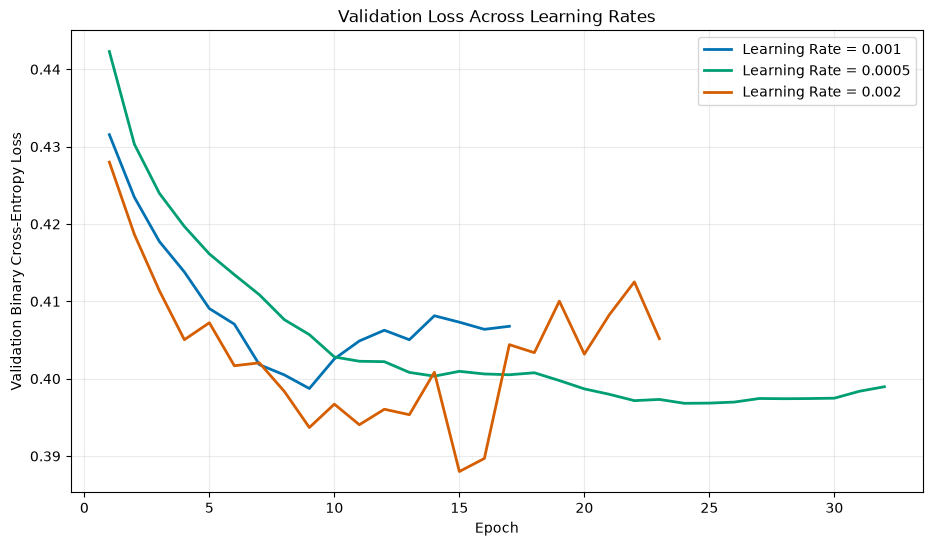

In [13]:
plt.figure(figsize=(11, 6))

learning_rate_colors = {
    "reference": "#0072B2",
    "learning_rate_0005": "#009E73",
    "learning_rate_002": "#D55E00"
}

learning_rate_labels = {
    "reference": "Learning Rate = 0.001",
    "learning_rate_0005": "Learning Rate = 0.0005",
    "learning_rate_002": "Learning Rate = 0.002"
}

for experiment_name in learning_rate_labels:
    history = experiment_histories[
        experiment_name
    ]

    epochs = range(
        1,
        len(history.history["val_loss"]) + 1
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label=learning_rate_labels[
            experiment_name
        ],
        color=learning_rate_colors[
            experiment_name
        ],
        linewidth=2
    )

plt.title(
    "Validation Loss Across Learning Rates"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

<h3 style="color:#D55E00;">Learning Rate Tuning Results</h3>

The learning rate of `0.002` produced the strongest overall validation performance.

Compared with the reference learning rate of `0.001`, it improved:

- Best Validation Loss from `0.3987` to `0.3880`.
- Macro Recall from `0.3638` to `0.3920`.
- Macro F1-score from `0.4713` to `0.4959`.

The lower learning rate of `0.0005` trained more gradually and required 32 epochs, but its final validation metrics remained below those produced by `0.002`.

The `0.002` experiment showed more fluctuation in validation loss because its parameter updates were larger. However, ModelCheckpoint preserved the best state from epoch 15, while EarlyStopping ended training at epoch 23 after eight epochs without improvement.

Therefore, `0.002` is selected as the learning rate for the remaining tuning experiments.

The next experiments will keep this learning rate fixed and change only the network size.

<h2 style="color:#0072B2;">6. Network Size Tuning</h2>

Network size determines the model's learning capacity.

A wider network contains more neurons in each layer and can learn a larger number of patterns. However, excessive width may increase overfitting.

A deeper network contains more hidden layers and can build more stages of representation. However, additional depth is not automatically useful when the input contains only 72 statistical features.

The selected learning-rate configuration uses two hidden layers:

$$
72 \rightarrow 32 \rightarrow 16 \rightarrow 4
$$

Two controlled architecture changes will be tested:

- Wider network: `72 → 64 → 32 → 4`
- Deeper network: `72 → 32 → 16 → 8 → 4`

All remaining values will stay fixed:

- Learning rate: 0.002.
- Dropout: 0.0.
- Batch size: 32.
- EarlyStopping patience: 8.
- Prediction threshold: 0.5.

In [14]:
wider_model, wider_history = (
    run_experiment(
        experiment_name="wider_64_32",
        hidden_units=(64, 32),
        learning_rate=0.002,
        dropout_rate=0.0,
        batch_size=32
    )
)

Experiment: wider_64_32
Hidden units: (64, 32)
Learning rate: 0.002
Dropout rate: 0.0
Batch size: 32
Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8142 - loss: 0.4271 - val_binary_accuracy: 0.8240 - val_loss: 0.4152
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8292 - loss: 0.3956 - val_binary_accuracy: 0.8307 - val_loss: 0.4002
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8343 - loss: 0.3831 - val_binary_accuracy: 0.8304 - val_loss: 0.3968
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8364 - loss: 0.3765 - val_binary_accuracy: 0.8331 - val_loss: 0.3949
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8387 - loss: 0.3716 - val_binary_accuracy: 0.8345 - val_loss: 0.3929
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8411 - loss: 0.3674 - val_binary_accuracy: 0.8355 - val_loss: 0.3909
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 

In [15]:
deeper_model, deeper_history = (
    run_experiment(
        experiment_name="deeper_32_16_8",
        hidden_units=(32, 16, 8),
        learning_rate=0.002,
        dropout_rate=0.0,
        batch_size=32
    )
)

Experiment: deeper_32_16_8
Hidden units: (32, 16, 8)
Learning rate: 0.002
Dropout rate: 0.0
Batch size: 32


Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8041 - loss: 0.4412 - val_binary_accuracy: 0.8187 - val_loss: 0.4167
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8253 - loss: 0.4027 - val_binary_accuracy: 0.8229 - val_loss: 0.4073
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8296 - loss: 0.3940 - val_binary_accuracy: 0.8235 - val_loss: 0.4054
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8322 - loss: 0.3881 - val_binary_accuracy: 0.8264 - val_loss: 0.4004
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8338 - loss: 0.3840 - val_binary_accuracy: 0.8270 - val_loss: 0.3975
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8360 - loss: 0.3805 - val_binary_accuracy: 0.8274 - val_loss: 0.3983
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8372 - loss: 0.3779 - val_binary_accuracy: 0.8269 - val_loss: 0.3992

In [16]:
results_table = pd.DataFrame(
    experiment_results
)

network_size_results = results_table[
    results_table["Experiment"].isin([
        "learning_rate_002",
        "wider_64_32",
        "deeper_32_16_8"
    ])
].copy()

display(
    network_size_results.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
2,learning_rate_002,"(32, 16)",0.002,0.0,32,23,15,0.3880,0.6869,0.3920,0.4959
3,wider_64_32,"(64, 32)",0.002,0.0,32,16,8,0.3855,0.7035,0.4060,0.5107
4,deeper_32_16_8,"(32, 16, 8)",0.002,0.0,32,28,20,0.3864,0.6885,0.3851,0.4920


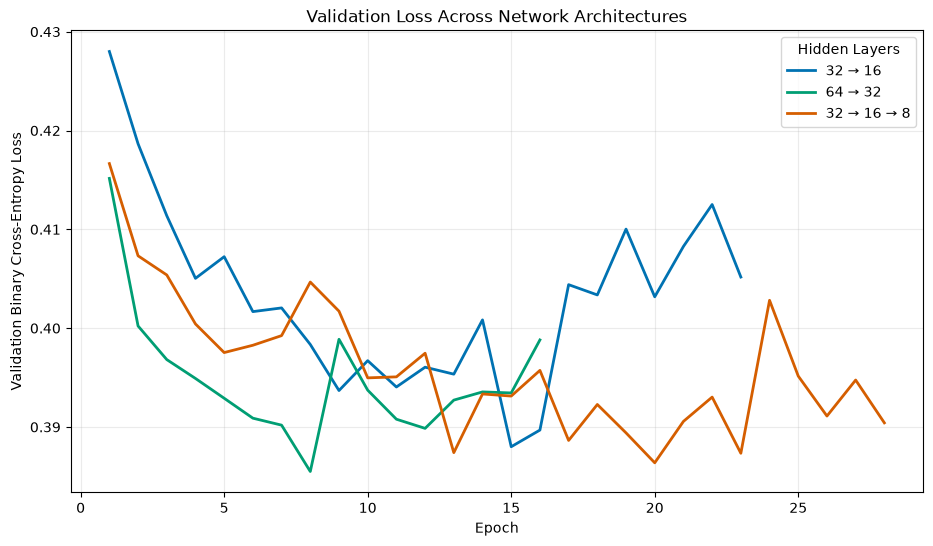

In [17]:
plt.figure(figsize=(11, 6))

architecture_labels = {
    "learning_rate_002": "32 → 16",
    "wider_64_32": "64 → 32",
    "deeper_32_16_8": "32 → 16 → 8"
}

architecture_colors = {
    "learning_rate_002": "#0072B2",
    "wider_64_32": "#009E73",
    "deeper_32_16_8": "#D55E00"
}

for experiment_name in architecture_labels:
    history = experiment_histories[
        experiment_name
    ]

    epochs = range(
        1,
        len(history.history["val_loss"]) + 1
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label=architecture_labels[
            experiment_name
        ],
        color=architecture_colors[
            experiment_name
        ],
        linewidth=2
    )

plt.title(
    "Validation Loss Across Network Architectures"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Binary Cross-Entropy Loss")
plt.legend(title="Hidden Layers")
plt.grid(alpha=0.25)
plt.show()

<h3 style="color:#D55E00;">Network Size Tuning Results</h3>

The wider network produced the strongest validation performance.

Changing the architecture from `32 → 16` to `64 → 32` improved:

- Best Validation Loss from `0.3880` to `0.3855`.
- Macro Precision from `0.6869` to `0.7035`.
- Macro Recall from `0.3920` to `0.4060`.
- Macro F1-score from `0.4959` to `0.5107`.

The wider network reached its best result at epoch 8 and stopped at epoch 16. It learned useful patterns faster than the original architecture while improving both precision and recall.

Adding a third hidden layer did not improve performance. The deeper `32 → 16 → 8` network achieved a slightly lower validation loss than the original network, but its Macro Recall and Macro F1-score were lower.

The inputs are 72 statistical ECG features rather than raw waveforms. Therefore, adding more transformation stages did not necessarily provide useful additional representations.

The `64 → 32` architecture is selected for the remaining experiments.

<h2 style="color:#0072B2;">7. Dropout Rate Tuning</h2>

Dropout randomly disables a proportion of layer outputs during training. This can reduce overfitting by preventing the network from depending too strongly on particular neurons.

Day 4 used a dropout rate of `0.3` together with Batch Normalization. That configuration reduced Macro Recall substantially, but the individual effect of Dropout was not isolated.

The selected wider network will now be tested with lighter Dropout values:

- `0.0`: selected wider model without Dropout.
- `0.1`: disables approximately 10% of layer outputs during training.
- `0.2`: disables approximately 20% of layer outputs during training.

Only the Dropout rate will change. The architecture, learning rate, batch size, callbacks, data, and threshold will remain fixed.

In [18]:
dropout_01_model, dropout_01_history = (
    run_experiment(
        experiment_name="dropout_01",
        hidden_units=(64, 32),
        learning_rate=0.002,
        dropout_rate=0.1,
        batch_size=32
    )
)

Experiment: dropout_01
Hidden units: (64, 32)
Learning rate: 0.002
Dropout rate: 0.1
Batch size: 32
Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.8089 - loss: 0.4373 - val_binary_accuracy: 0.8214 - val_loss: 0.4163
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8245 - loss: 0.4069 - val_binary_accuracy: 0.8256 - val_loss: 0.4074
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8270 - loss: 0.3958 - val_binary_accuracy: 0.8291 - val_loss: 0.4063
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8310 - loss: 0.3899 - val_binary_accuracy: 0.8277 - val_loss: 0.4083
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - binary_accuracy: 0.8328 - loss: 0.3853 - val_binary_accuracy: 0.8315 - val_loss: 0.4032
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8334 - loss: 0.3813 - val_binary_accuracy: 0.8312 - val_loss: 0.3966
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2

In [19]:
dropout_02_model, dropout_02_history = (
    run_experiment(
        experiment_name="dropout_02",
        hidden_units=(64, 32),
        learning_rate=0.002,
        dropout_rate=0.2,
        batch_size=32
    )
)

Experiment: dropout_02
Hidden units: (64, 32)
Learning rate: 0.002
Dropout rate: 0.2
Batch size: 32
Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.8039 - loss: 0.4487 - val_binary_accuracy: 0.8209 - val_loss: 0.4154
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8194 - loss: 0.4174 - val_binary_accuracy: 0.8208 - val_loss: 0.4066
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8236 - loss: 0.4062 - val_binary_accuracy: 0.8265 - val_loss: 0.4024
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8256 - loss: 0.4017 - val_binary_accuracy: 0.8243 - val_loss: 0.4019
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8270 - loss: 0.3972 - val_binary_accuracy: 0.8263 - val_loss: 0.4031
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.8279 - loss: 0.3922 - val_binary_accuracy: 0.8271 - val_loss: 0.3979
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2

In [20]:
results_table = pd.DataFrame(
    experiment_results
)

dropout_results = results_table[
    results_table["Experiment"].isin([
        "wider_64_32",
        "dropout_01",
        "dropout_02"
    ])
].copy()

display(
    dropout_results.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
3,wider_64_32,"(64, 32)",0.002,0.0,32,16,8,0.3855,0.7035,0.4060,0.5107
5,dropout_01,"(64, 32)",0.002,0.1,32,28,20,0.3768,0.7253,0.3587,0.4752
6,dropout_02,"(64, 32)",0.002,0.2,32,30,22,0.3755,0.7421,0.3322,0.4512


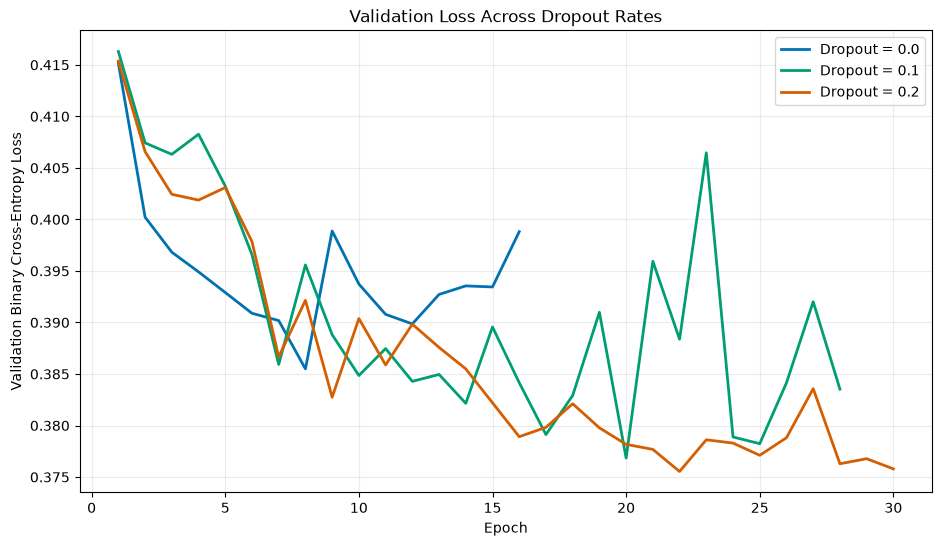

In [21]:
plt.figure(figsize=(11, 6))

dropout_labels = {
    "wider_64_32": "Dropout = 0.0",
    "dropout_01": "Dropout = 0.1",
    "dropout_02": "Dropout = 0.2"
}

dropout_colors = {
    "wider_64_32": "#0072B2",
    "dropout_01": "#009E73",
    "dropout_02": "#D55E00"
}

for experiment_name in dropout_labels:
    history = experiment_histories[
        experiment_name
    ]

    epochs = range(
        1,
        len(history.history["val_loss"]) + 1
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label=dropout_labels[
            experiment_name
        ],
        color=dropout_colors[
            experiment_name
        ],
        linewidth=2
    )

plt.title(
    "Validation Loss Across Dropout Rates"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

<h3 style="color:#D55E00;">Dropout Tuning Results</h3>

Dropout reduced validation loss and increased precision, but it substantially reduced disease recall.

Compared with no Dropout:

- Dropout `0.1` reduced Macro Recall from `0.4060` to `0.3587`.
- Dropout `0.2` reduced Macro Recall further to `0.3322`.
- Macro F1-score also decreased as the Dropout rate increased.

The lower validation loss does not mean that the Dropout models are better for this project. Binary Cross-Entropy evaluates probability quality across all positive and negative labels, while the fixed threshold determines which probabilities become positive disease predictions.

Because negative labels are more frequent, a conservative model can achieve a lower loss and higher precision while still missing more true diseases.

The results also clarify the Day 4 finding. Dropout itself contributed to the recall reduction; the problem was not caused only by Batch Normalization.

Since disease detection is the project's priority, the no-Dropout configuration is selected:

- Architecture: `64 → 32`
- Learning rate: `0.002`
- Dropout: `0.0`

The next experiment will keep these values fixed and change only the batch size.

<h2 style="color:#0072B2;">8. Batch Size Tuning</h2>

Batch size determines how many training samples are processed before one parameter update.

A smaller batch size produces more updates during each epoch. These updates can be noisier, but the noise may help the model find a solution that generalizes well.

A larger batch size produces fewer and more stable updates. It can train more efficiently, but it may converge to a different solution.

Three batch sizes will be compared:

- `16`: smaller and noisier updates.
- `32`: the selected configuration's current value.
- `64`: larger and more stable updates.

Only batch size will change. The selected architecture, learning rate, Dropout rate, callbacks, validation data, and prediction threshold will remain fixed.

In [22]:
batch_16_model, batch_16_history = (
    run_experiment(
        experiment_name="batch_size_16",
        hidden_units=(64, 32),
        learning_rate=0.002,
        dropout_rate=0.0,
        batch_size=16
    )
)

Experiment: batch_size_16
Hidden units: (64, 32)
Learning rate: 0.002
Dropout rate: 0.0
Batch size: 16
Epoch 1/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.8173 - loss: 0.4221 - val_binary_accuracy: 0.8264 - val_loss: 0.4165
Epoch 2/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.8301 - loss: 0.3934 - val_binary_accuracy: 0.8314 - val_loss: 0.4031
Epoch 3/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - binary_accuracy: 0.8350 - loss: 0.3814 - val_binary_accuracy: 0.8313 - val_loss: 0.4010
Epoch 4/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8376 - loss: 0.3746 - val_binary_accuracy: 0.8318 - val_loss: 0.4022
Epoch 5/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8403 - loss: 0.3697 - val_binary_accuracy: 0.8328 - val_loss: 0.3894
Epoch 6/100
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.8415 - loss: 0.3661 - val_binary_accuracy: 0.8311 - val_loss: 0.3894
Epoch 7/100
1068/1068 ━━━━━

In [23]:
batch_64_model, batch_64_history = (
    run_experiment(
        experiment_name="batch_size_64",
        hidden_units=(64, 32),
        learning_rate=0.002,
        dropout_rate=0.0,
        batch_size=64
    )
)

Experiment: batch_size_64
Hidden units: (64, 32)
Learning rate: 0.002
Dropout rate: 0.0
Batch size: 64
Epoch 1/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8102 - loss: 0.4340 - val_binary_accuracy: 0.8201 - val_loss: 0.4166
Epoch 2/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - binary_accuracy: 0.8271 - loss: 0.3998 - val_binary_accuracy: 0.8260 - val_loss: 0.4075
Epoch 3/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8321 - loss: 0.3875 - val_binary_accuracy: 0.8296 - val_loss: 0.4121
Epoch 4/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8354 - loss: 0.3797 - val_binary_accuracy: 0.8306 - val_loss: 0.4071
Epoch 5/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8390 - loss: 0.3735 - val_binary_accuracy: 0.8304 - val_loss: 0.4091
Epoch 6/100
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8406 - loss: 0.3690 - val_binary_accuracy: 0.8328 - val_loss: 0.3993
Epoch 7/100
267/267 ━━━━━━━━━━━━━━━━━━

In [24]:
results_table = pd.DataFrame(
    experiment_results
)

batch_size_results = results_table[
    results_table["Experiment"].isin([
        "wider_64_32",
        "batch_size_16",
        "batch_size_64"
    ])
].copy()

display(
    batch_size_results.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
3,wider_64_32,"(64, 32)",0.002,0.0,32,16,8,0.3855,0.7035,0.4060,0.5107
7,batch_size_16,"(64, 32)",0.002,0.0,16,16,8,0.3859,0.6990,0.3967,0.4945
8,batch_size_64,"(64, 32)",0.002,0.0,64,14,6,0.3993,0.6946,0.3814,0.4890


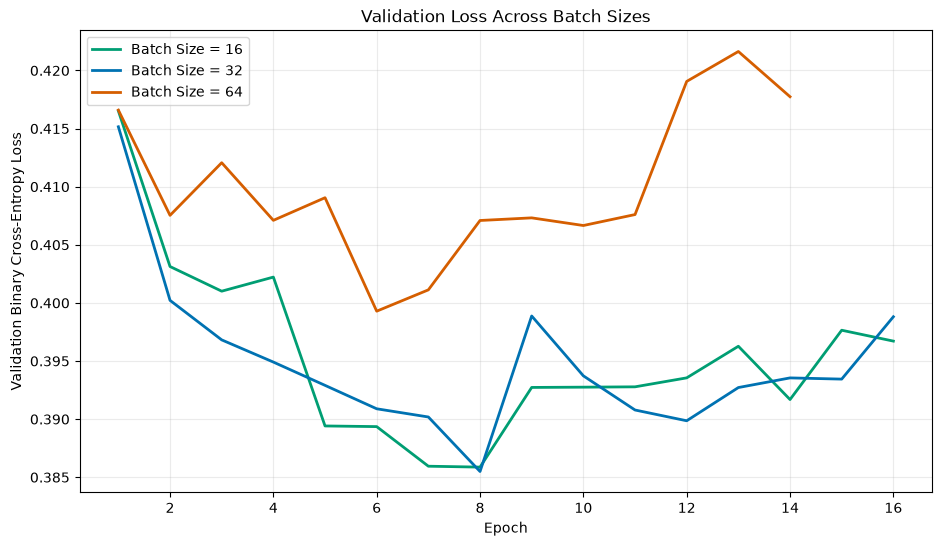

In [25]:
plt.figure(figsize=(11, 6))

batch_labels = {
    "batch_size_16": "Batch Size = 16",
    "wider_64_32": "Batch Size = 32",
    "batch_size_64": "Batch Size = 64"
}

batch_colors = {
    "batch_size_16": "#009E73",
    "wider_64_32": "#0072B2",
    "batch_size_64": "#D55E00"
}

for experiment_name in batch_labels:
    history = experiment_histories[
        experiment_name
    ]

    epochs = range(
        1,
        len(history.history["val_loss"]) + 1
    )

    plt.plot(
        epochs,
        history.history["val_loss"],
        label=batch_labels[
            experiment_name
        ],
        color=batch_colors[
            experiment_name
        ],
        linewidth=2
    )

plt.title(
    "Validation Loss Across Batch Sizes"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

<h3 style="color:#D55E00;">Batch Size Tuning Results</h3>

Batch size `32` produced the strongest overall validation result.

The smaller batch size of `16` doubled the number of updates per epoch from approximately 534 to 1,068. However, these additional and noisier updates did not improve validation performance.

The larger batch size of `64` reduced the number of updates to approximately 267 per epoch, but it produced the highest validation loss and the lowest recall among the tested batch sizes.

Therefore, the selected model configuration is:

- Hidden layers: `64 → 32`
- Learning rate: `0.002`
- Dropout rate: `0.0`
- Batch size: `32`
- Hidden activation: ReLU
- Output activation: Sigmoid
- Loss: Binary Cross-Entropy
- EarlyStopping patience: 8

At the default threshold of `0.5`, this model achieved:

- Best Validation Loss: `0.3855`
- Macro Precision: `0.7035`
- Macro Recall: `0.4060`
- Macro F1-score: `0.5107`

All four required tuning priorities have now been evaluated by changing one variable at a time.

The next step will preserve the selected model and tune only the prediction threshold using validation data.

<h2 style="color:#0072B2;">9. Validation Threshold Tuning</h2>

The sigmoid output produces four probabilities for every ECG. The default threshold of `0.5` converts each probability into a binary prediction.

For a disease class:

$$
\hat{y}=1 \quad \text{when} \quad p \geq t
$$

Lowering the threshold usually increases Recall because more probabilities become positive predictions. However, it can also reduce Precision by increasing false-positive predictions.

Selecting a threshold using Recall alone would be unsafe. A threshold close to zero could produce very high Recall simply by predicting almost every disease as positive.

The threshold will therefore be selected using the Macro F2-score:

$$
F_2 =
\frac{5 \times Precision \times Recall}
{4 \times Precision + Recall}
$$

Unlike F1, F2 gives Recall more importance than Precision while still penalizing excessive false-positive predictions.

Thresholds will be evaluated using the validation set only. The test set will remain untouched until the threshold and model configuration are finalized.

In [26]:
from sklearn.metrics import fbeta_score


selected_model_name = "wider_64_32"

selected_model = experiment_models[
    selected_model_name
]

selected_validation_probabilities = (
    experiment_probabilities[
        selected_model_name
    ]
)


threshold_values = np.arange(
    0.10,
    0.501,
    0.025
)

threshold_results = []


for threshold in threshold_values:
    validation_predictions = (
        selected_validation_probabilities
        >= threshold
    ).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_validation_array,
            validation_predictions,
            average="macro",
            zero_division=0
        )
    )

    f2 = fbeta_score(
        y_validation_array,
        validation_predictions,
        beta=2,
        average="macro",
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "Macro F2": f2
    })


threshold_table = pd.DataFrame(
    threshold_results
)

display(
    threshold_table.round(4)
)

,Threshold,Macro Precision,Macro Recall,Macro F1,Macro F2
0,0.100,0.3489,0.8811,0.4988,0.6734
1,0.125,0.3800,0.8514,0.5237,0.6796
2,0.150,0.4090,0.8212,0.5440,0.6807
3,0.175,0.4349,0.7960,0.5606,0.6804
4,0.200,0.4611,0.7593,0.5716,0.6700
5,0.225,0.4863,0.7312,0.5821,0.6624
6,0.250,0.5076,0.7005,0.5869,0.6495
7,0.275,0.5311,0.6711,0.5918,0.6365
8,0.300,0.5481,0.6353,0.5876,0.6151
9,0.325,0.5684,0.6024,0.5843,0.5949


In [27]:
best_threshold_row = threshold_table.loc[
    threshold_table["Macro F2"].idxmax()
]

selected_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    "Selected threshold:",
    round(selected_threshold, 3)
)

print(
    "Validation Macro Precision:",
    round(
        best_threshold_row[
            "Macro Precision"
        ],
        4
    )
)

print(
    "Validation Macro Recall:",
    round(
        best_threshold_row[
            "Macro Recall"
        ],
        4
    )
)

print(
    "Validation Macro F1:",
    round(
        best_threshold_row[
            "Macro F1"
        ],
        4
    )
)

print(
    "Validation Macro F2:",
    round(
        best_threshold_row[
            "Macro F2"
        ],
        4
    )
)

Selected threshold: 0.15
Validation Macro Precision: 0.409
Validation Macro Recall: 0.8212
Validation Macro F1: 0.544
Validation Macro F2: 0.6807


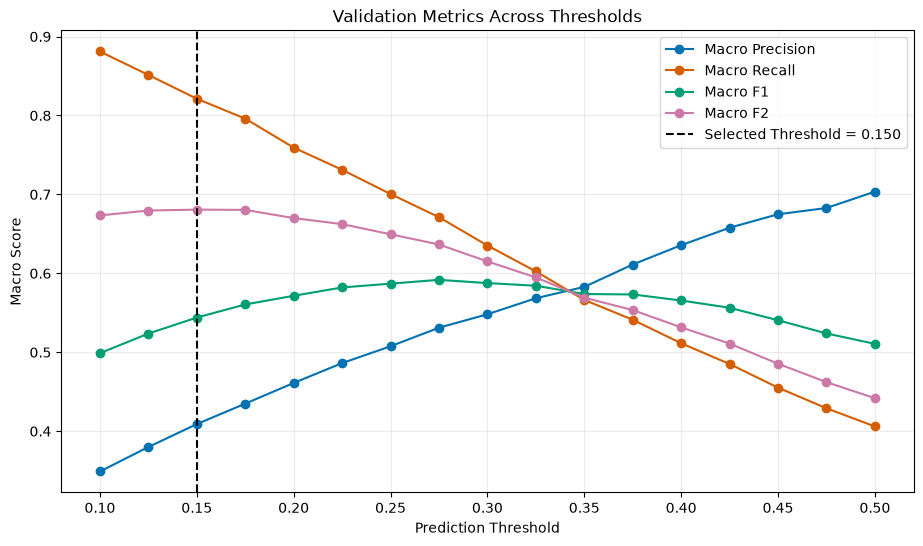

In [28]:
plt.figure(figsize=(11, 6))

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Macro Precision"],
    marker="o",
    label="Macro Precision",
    color="#0072B2"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Macro Recall"],
    marker="o",
    label="Macro Recall",
    color="#D55E00"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Macro F1"],
    marker="o",
    label="Macro F1",
    color="#009E73"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Macro F2"],
    marker="o",
    label="Macro F2",
    color="#CC79A7"
)

plt.axvline(
    selected_threshold,
    color="black",
    linestyle="--",
    label=(
        f"Selected Threshold = "
        f"{selected_threshold:.3f}"
    )
)

plt.title(
    "Validation Metrics Across Thresholds"
)
plt.xlabel("Prediction Threshold")
plt.ylabel("Macro Score")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [29]:
from sklearn.metrics import classification_report

selected_validation_predictions = (
    selected_validation_probabilities
    >= selected_threshold
).astype(int)

print(
    classification_report(
        y_validation_array,
        selected_validation_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.42      0.85      0.56       540
        STTC       0.36      0.89      0.51       528
          CD       0.45      0.80      0.57       495
         HYP       0.41      0.74      0.53       268

   micro avg       0.40      0.83      0.54      1831
   macro avg       0.41      0.82      0.54      1831
weighted avg       0.41      0.83      0.55      1831
 samples avg       0.31      0.47      0.35      1831



<h3 style="color:#D55E00;">Threshold Tuning Results</h3>

The Macro F2-score reached its highest value at a threshold of `0.15`.

Changing the threshold from `0.5` to `0.15` changed the validation metrics as follows:

- Macro Precision decreased from `0.7035` to `0.4090`.
- Macro Recall increased from `0.4060` to `0.8212`.
- Macro F1-score increased from `0.5107` to `0.5440`.
- Macro F2-score increased from `0.4418` to `0.6807`.

The decrease in precision is the cost of detecting substantially more true disease cases. However, the threshold was not selected using Recall alone. It achieved the highest Macro F2-score, which penalizes false-positive predictions while giving more importance to missed diseases.

At the selected threshold, the validation recall for every class was:

- MI: `0.85`
- STTC: `0.89`
- CD: `0.80`
- HYP: `0.74`

Therefore, `0.15` is selected as the final global prediction threshold.

The model architecture, training configuration, and threshold are now fixed. The test set can finally be used once for the official final evaluation.

<h2 style="color:#0072B2;">10. Final Test Evaluation</h2>

All model and threshold decisions were completed using the validation set.

The final configuration is:

- Input features: 72.
- Hidden layers: 64 and 32 neurons.
- Hidden activation: ReLU.
- Output layer: four independent sigmoid neurons.
- Learning rate: 0.002.
- Dropout rate: 0.0.
- Batch size: 32.
- EarlyStopping patience: 8.
- Selected checkpoint epoch: 8.
- Prediction threshold: 0.15.

The saved ModelCheckpoint will be loaded before evaluation. This ensures that the final evaluation uses the exact model state with the best validation loss.

The test set will now be used once to estimate performance on unseen ECG recordings.

In [30]:
final_model_path = (
    CHECKPOINT_DIR / "wider_64_32.keras"
)

final_model = tf.keras.models.load_model(
    final_model_path
)

print(
    "Loaded final model:",
    final_model_path
)

final_model.summary()

Loaded final model: checkpoints/wider_64_32.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,654 (80.68 KB)

 Trainable params: 6,884 (26.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,770 (53.79 KB)

In [31]:
final_test_loss, final_test_binary_accuracy = (
    final_model.evaluate(
        X_test_scaled,
        y_test_array,
        verbose=0
    )
)

final_test_probabilities = (
    final_model.predict(
        X_test_scaled,
        verbose=0
    )
)

final_test_predictions = (
    final_test_probabilities
    >= selected_threshold
).astype(int)

print(
    "Final test loss:",
    round(final_test_loss, 4)
)

print(
    "Final test binary accuracy:",
    round(
        final_test_binary_accuracy,
        4
    )
)

print(
    "Selected threshold:",
    selected_threshold
)

Final test loss: 0.3963
Final test binary accuracy: 0.8306
Selected threshold: 0.15


In [32]:
print(
    classification_report(
        y_test_array,
        final_test_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          MI       0.40      0.83      0.54       550
        STTC       0.33      0.87      0.48       521
          CD       0.41      0.79      0.54       496
         HYP       0.39      0.73      0.51       262

   micro avg       0.38      0.81      0.52      1829
   macro avg       0.38      0.80      0.52      1829
weighted avg       0.38      0.81      0.52      1829
 samples avg       0.29      0.46      0.33      1829



In [33]:
final_test_precision, final_test_recall, (
    final_test_f1
), _ = precision_recall_fscore_support(
    y_test_array,
    final_test_predictions,
    average="macro",
    zero_division=0
)

final_test_f2 = fbeta_score(
    y_test_array,
    final_test_predictions,
    beta=2,
    average="macro",
    zero_division=0
)

print(
    "Final Test Macro Precision:",
    round(final_test_precision, 4)
)

print(
    "Final Test Macro Recall:",
    round(final_test_recall, 4)
)

print(
    "Final Test Macro F1:",
    round(final_test_f1, 4)
)

print(
    "Final Test Macro F2:",
    round(final_test_f2, 4)
)

Final Test Macro Precision: 0.3827
Final Test Macro Recall: 0.8035
Final Test Macro F1: 0.5166
Final Test Macro F2: 0.6561


In [34]:
default_test_predictions = (
    final_test_probabilities >= 0.5
).astype(int)

default_test_precision, (
    default_test_recall
), default_test_f1, _ = (
    precision_recall_fscore_support(
        y_test_array,
        default_test_predictions,
        average="macro",
        zero_division=0
    )
)

default_test_f2 = fbeta_score(
    y_test_array,
    default_test_predictions,
    beta=2,
    average="macro",
    zero_division=0
)

threshold_test_comparison = pd.DataFrame({
    "Threshold": [
        0.5,
        selected_threshold
    ],
    "Macro Precision": [
        default_test_precision,
        final_test_precision
    ],
    "Macro Recall": [
        default_test_recall,
        final_test_recall
    ],
    "Macro F1": [
        default_test_f1,
        final_test_f1
    ],
    "Macro F2": [
        default_test_f2,
        final_test_f2
    ]
})

display(
    threshold_test_comparison.round(4)
)

,Threshold,Macro Precision,Macro Recall,Macro F1,Macro F2
0,0.50,0.6766,0.3821,0.4837,0.4167
1,0.15,0.3827,0.8035,0.5166,0.6561


<h2 style="color:#0072B2;">11. Final Baseline Comparison</h2>

The selected neural network must be compared with the same Logistic Regression baseline used during Day 4.

For a fair comparison, Logistic Regression will use:

- The same 72 standardized features.
- The same four disease targets.
- The same official training and test folds.
- The same Macro Precision, Recall, F1, and F2 calculations.

The baseline will not influence any further tuning decision. It is retrained only to assemble the final Sprint Review evidence.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier


baseline_model = OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED
    )
)

baseline_model.fit(
    X_train_scaled,
    y_train_array
)

baseline_test_predictions = (
    baseline_model.predict(
        X_test_scaled
    )
)


baseline_precision, baseline_recall, (
    baseline_f1
), _ = precision_recall_fscore_support(
    y_test_array,
    baseline_test_predictions,
    average="macro",
    zero_division=0
)

baseline_f2 = fbeta_score(
    y_test_array,
    baseline_test_predictions,
    beta=2,
    average="macro",
    zero_division=0
)


final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "Tuned Neural Network"
    ],
    "Threshold": [
        "Default",
        round(selected_threshold, 3)
    ],
    "Macro Precision": [
        baseline_precision,
        final_test_precision
    ],
    "Macro Recall": [
        baseline_recall,
        final_test_recall
    ],
    "Macro F1": [
        baseline_f1,
        final_test_f1
    ],
    "Macro F2": [
        baseline_f2,
        final_test_f2
    ]
})

display(
    final_comparison.round(4)
)

,Model,Threshold,Macro Precision,Macro Recall,Macro F1,Macro F2
0,Logistic Regression Baseline,Default,0.4086,0.6642,0.5037,0.5879
1,Tuned Neural Network,0.15,0.3827,0.8035,0.5166,0.6561


<h3 style="color:#D55E00;">Final Test Results</h3>

The tuned neural network generalized consistently from validation to test data.

At the selected threshold of `0.15`, it achieved:

- Test Binary Cross-Entropy Loss: `0.3963`
- Macro Precision: `0.3827`
- Macro Recall: `0.8035`
- Macro F1-score: `0.5166`
- Macro F2-score: `0.6561`

The validation Macro Recall was `0.8212`, while the test Macro Recall was `0.8035`. The relatively small difference indicates that the threshold-selection result generalized consistently to unseen ECG recordings.

The disease-specific test recall was:

- MI: `0.83`
- STTC: `0.87`
- CD: `0.79`
- HYP: `0.73`

Changing the threshold from `0.5` to `0.15` increased Test Macro Recall from `0.3821` to `0.8035`. Macro F1-score also increased from `0.4837` to `0.5166`.

Precision decreased from `0.6766` to `0.3827`. This is the expected cost of detecting more true disease cases. The threshold was selected using Macro F2 rather than Recall alone, ensuring that false-positive predictions were still included in the selection criterion.

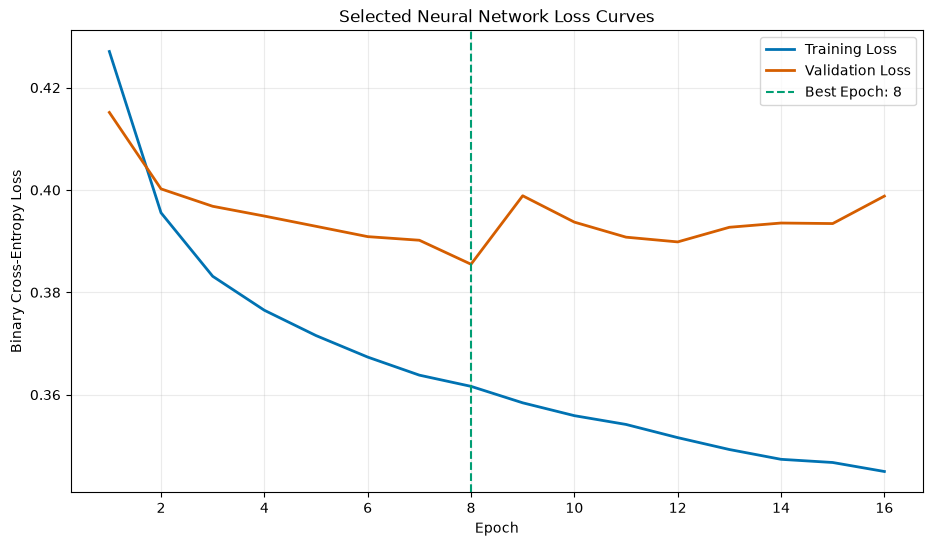

In [36]:
final_history = experiment_histories[
    "wider_64_32"
]

final_epochs = range(
    1,
    len(final_history.history["loss"]) + 1
)

final_best_epoch = (
    np.argmin(
        final_history.history["val_loss"]
    ) + 1
)

plt.figure(figsize=(11, 6))

plt.plot(
    final_epochs,
    final_history.history["loss"],
    label="Training Loss",
    color="#0072B2",
    linewidth=2
)

plt.plot(
    final_epochs,
    final_history.history["val_loss"],
    label="Validation Loss",
    color="#D55E00",
    linewidth=2
)

plt.axvline(
    final_best_epoch,
    color="#009E73",
    linestyle="--",
    label=f"Best Epoch: {final_best_epoch}"
)

plt.title(
    "Selected Neural Network Loss Curves"
)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

<h2 style="color:#0072B2;">12. Complete Tuning Evidence</h2>

The following table contains every controlled tuning experiment.

Each experiment changed one hyperparameter relative to the configuration selected during the preceding tuning stage. This provides traceable evidence for every final configuration choice.

In [37]:
complete_experiment_table = pd.DataFrame(
    experiment_results
)

display(
    complete_experiment_table.round(4)
)

,Experiment,Hidden Units,Learning Rate,Dropout,Batch Size,Epochs Trained,Best Epoch,Best Validation Loss,Macro Precision,Macro Recall,Macro F1
0,reference,"(32, 16)",0.0010,0.0,32,17,9,0.3987,0.6886,0.3638,0.4713
1,learning_rate_0005,"(32, 16)",0.0005,0.0,32,32,24,0.3968,0.6793,0.3875,0.4912
2,learning_rate_002,"(32, 16)",0.0020,0.0,32,23,15,0.3880,0.6869,0.3920,0.4959
3,wider_64_32,"(64, 32)",0.0020,0.0,32,16,8,0.3855,0.7035,0.4060,0.5107
4,deeper_32_16_8,"(32, 16, 8)",0.0020,0.0,32,28,20,0.3864,0.6885,0.3851,0.4920
5,dropout_01,"(64, 32)",0.0020,0.1,32,28,20,0.3768,0.7253,0.3587,0.4752
6,dropout_02,"(64, 32)",0.0020,0.2,32,30,22,0.3755,0.7421,0.3322,0.4512
7,batch_size_16,"(64, 32)",0.0020,0.0,16,16,8,0.3859,0.6990,0.3967,0.4945
8,batch_size_64,"(64, 32)",0.0020,0.0,64,14,6,0.3993,0.6946,0.3814,0.4890


In [38]:
tuning_decisions = pd.DataFrame({
    "Tuning Stage": [
        "Learning Rate",
        "Network Size",
        "Dropout Rate",
        "Batch Size",
        "Threshold"
    ],
    "Values Compared": [
        "0.0005, 0.001, 0.002",
        "32-16, 64-32, 32-16-8",
        "0.0, 0.1, 0.2",
        "16, 32, 64",
        "0.10 to 0.50"
    ],
    "Selected Value": [
        "0.002",
        "64-32",
        "0.0",
        "32",
        "0.15"
    ],
    "Selection Reason": [
        "Best validation loss, recall and F1",
        "Best validation loss, recall and F1",
        "Best recall and F1",
        "Best validation loss, recall and F1",
        "Highest validation Macro F2"
    ]
})

display(tuning_decisions)

,Tuning Stage,Values Compared,Selected Value,Selection Reason
0,Learning Rate,"0.0005, 0.001, 0.002",0.002,"Best validation loss, recall and F1"
1,Network Size,"32-16, 64-32, 32-16-8",64-32,"Best validation loss, recall and F1"
2,Dropout Rate,"0.0, 0.1, 0.2",0.0,Best recall and F1
3,Batch Size,"16, 32, 64",32,"Best validation loss, recall and F1"
4,Threshold,0.10 to 0.50,0.15,Highest validation Macro F2


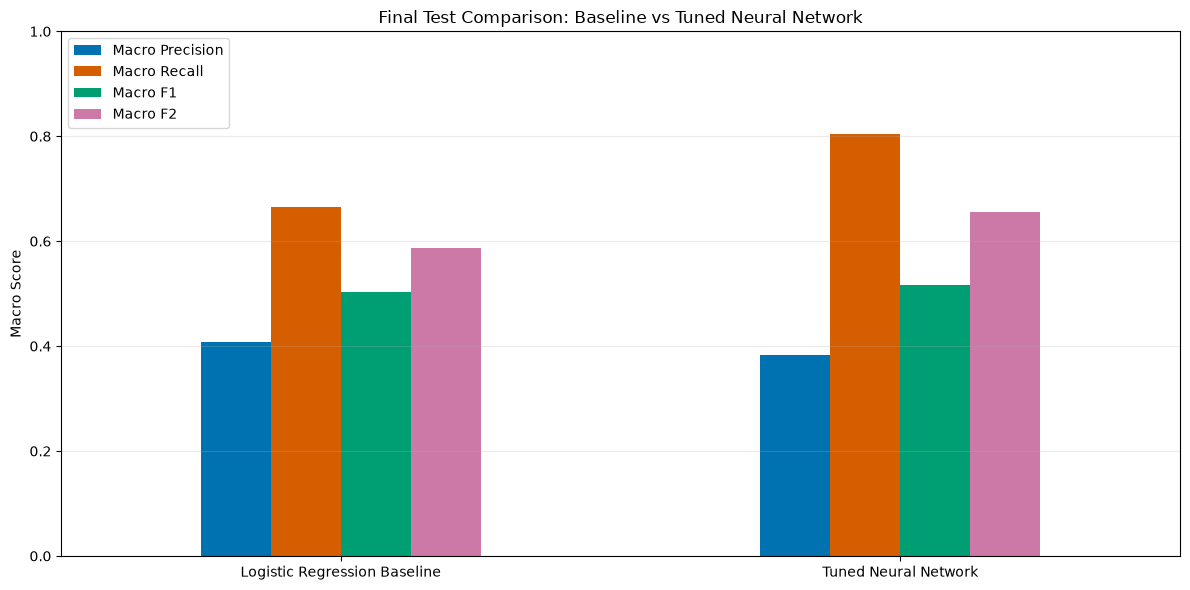

In [39]:
comparison_plot = final_comparison.set_index(
    "Model"
)[[
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Macro F2"
]]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=[
        "#0072B2",
        "#D55E00",
        "#009E73",
        "#CC79A7"
    ]
)

plt.title(
    "Final Test Comparison: Baseline vs Tuned Neural Network"
)
plt.xlabel("")
plt.ylabel("Macro Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="upper left")
plt.grid(
    axis="y",
    alpha=0.25
)
plt.tight_layout()
plt.show()

<h3 style="color:#D55E00;">Did the Neural Network Beat the Baseline?</h3>

Yes. The tuned neural network beat the Logistic Regression baseline according to the project's primary metrics.

The Logistic Regression baseline achieved:

- Macro Precision: `0.4086`
- Macro Recall: `0.6642`
- Macro F1-score: `0.5037`
- Macro F2-score: `0.5879`

The tuned neural network achieved:

- Macro Precision: `0.3827`
- Macro Recall: `0.8035`
- Macro F1-score: `0.5166`
- Macro F2-score: `0.6561`

Compared with the baseline, the neural network improved:

- Macro Recall by approximately `0.1393`.
- Macro F1-score by approximately `0.0129`.
- Macro F2-score by approximately `0.0682`.

Macro Precision decreased by approximately `0.0259`.

This trade-off is appropriate for the current project goal. A false-positive prediction can be reviewed by a medical professional or followed by additional testing, while a false-negative prediction may incorrectly classify a patient with a cardiac condition as disease-free.

Therefore, the tuned neural network earns its place over the simpler baseline for the current high-recall screening objective.

<h2 style="color:#0072B2;">13. Sprint 1 Review</h2>

### Sprint Goal

Build and understand the first deep-learning pipeline for multi-label cardiac diagnosis using PTB-XL, then compare it fairly with a classical machine-learning baseline.

### Completed Work

- Finalized the PTB-XL dataset and official fold-based split.
- Extracted 72 statistical features from 12 ECG leads.
- Created four independent disease targets: MI, STTC, CD, and HYP.
- Established a Logistic Regression baseline.
- Explained neural-network architecture, activations, forward propagation, loss, Backpropagation, and optimizers.
- Compared multiple learning rates.
- Built and trained Keras Sequential networks.
- Applied and evaluated Batch Normalization and Dropout.
- Diagnosed training and validation loss curves.
- Added EarlyStopping and ModelCheckpoint.
- Tuned learning rate, network size, Dropout rate, and batch size.
- Selected a threshold using validation Macro F2.
- Evaluated the final fixed configuration once on the official test fold.
- Produced a final metric table comparing the tuned network with the baseline.

### Final Neural Network

$$
72 \rightarrow 64 \rightarrow 32 \rightarrow 4
$$

- Hidden activation: ReLU
- Output activation: Sigmoid
- Optimizer: Adam
- Learning rate: 0.002
- Loss: Binary Cross-Entropy
- Dropout: 0.0
- Batch size: 32
- EarlyStopping patience: 8
- Best epoch: 8
- Final threshold: 0.15

### Sprint Outcome

The Sprint 1 goal was achieved.

The tuned neural network increased Test Macro Recall from `0.6642` for Logistic Regression to `0.8035`. It also achieved higher Macro F1 and Macro F2 scores than the baseline.

The current model is suitable as a high-recall baseline for the next project sprint, but it is not a clinical diagnostic system.

<h2 style="color:#0072B2;">14. Acceptance Criteria</h2>

| Acceptance Criterion | Status | Evidence |
|---|---|---|
| Dataset finalized | Complete | 21,388 ECG recordings |
| Reproducible official splits | Complete | PTB-XL folds 1–8, 9, and 10 |
| Classical baseline trained | Complete | One-vs-Rest Logistic Regression |
| Keras network built and trained | Complete | Sequential 72-64-32-4 model |
| Correct multi-label output and loss | Complete | Four sigmoid outputs and Binary Cross-Entropy |
| Loss curves diagnosed | Complete | Training and validation curves |
| Dropout and Batch Normalization evaluated | Complete | Day 4 and Day 5 comparisons |
| Hyperparameters tuned systematically | Complete | One-variable-at-a-time experiments |
| EarlyStopping applied | Complete | Training stopped after patience limit |
| Best model checkpoint saved | Complete | `wider_64_32.keras` |
| Baseline and network compared | Complete | Final test metric table |
| Results documented in Markdown | Complete | Notebook narrative and conclusions |
| Notebook runs without errors | Ready for final restart-and-run verification | Run all cells before submission |
| Git commits and feature branch | Pending user Git action | Commit after final verification |
| Pull request approved and merged | Pending mentor approval | External Sprint Review action |

<h2 style="color:#0072B2;">15. Sprint 1 Retrospective</h2>

### What Went Well

- The complete neural-network training process was connected to the underlying concepts rather than treated as a black box.
- Official PTB-XL folds prevented random patient leakage between training, validation, and test data.
- The final baseline comparison used the same data, targets, features, and folds.
- Changing one hyperparameter at a time made the effect of each experiment understandable.
- EarlyStopping prevented unnecessary training and restored the best weights.
- ModelCheckpoint preserved the best model independently of later epochs.
- Precision, Recall, F1, and F2 revealed limitations that Binary Accuracy alone concealed.
- Threshold tuning substantially improved disease detection.
- The tuned neural network finally outperformed Logistic Regression on the project's primary metrics.

### What Could Be Improved

- Extracting summary statistics compresses every ECG lead into six values and removes waveform order and morphology.
- A single global threshold may not be optimal for all four diseases.
- The model still produces many false-positive predictions because high Recall was prioritized.
- Experiment metadata is stored inside the notebook rather than in a dedicated experiment-tracking system.
- CPU-only training made repeated experiments less efficient.
- The notebook regenerates all 72 features from the raw ECG files whenever it is restarted.

### Concrete Change for Sprint 2

Every experiment will be logged from the beginning in a structured file or experiment-tracking system, including its architecture, learning rate, batch size, threshold, validation metrics, test status, and saved-model path.

### Sprint 2 Backlog

- Save the extracted 72-feature table to avoid repeated ECG processing.
- Investigate separate validation-selected thresholds for MI, STTC, CD, and HYP.
- Add confusion-matrix-style counts for every disease.
- Compare summary-feature networks with a 1D CNN trained on raw ECG waveforms.
- Analyze false-positive and false-negative ECG cases.
- Add structured experiment tracking.

<h2 style="color:#0072B2;">16. Day 5 and Week 6 Conclusion</h2>

Day 5 completed the neural-network tuning, evaluation, Sprint Review, and Retrospective requirements.

The tuning process evaluated learning rate, network size, Dropout rate, and batch size systematically. EarlyStopping stopped unproductive training, while ModelCheckpoint preserved the best model state.

The selected architecture was:

$$
72 \rightarrow 64 \rightarrow 32 \rightarrow 4
$$

The final model used Adam with a learning rate of `0.002`, no Dropout, a batch size of `32`, and a validation-selected threshold of `0.15`.

On the official test fold, it achieved:

- Macro Precision: `0.3827`
- Macro Recall: `0.8035`
- Macro F1-score: `0.5166`
- Macro F2-score: `0.6561`

The Logistic Regression baseline achieved:

- Macro Precision: `0.4086`
- Macro Recall: `0.6642`
- Macro F1-score: `0.5037`
- Macro F2-score: `0.5879`

The tuned neural network therefore outperformed the baseline in Recall, F1, and F2. Its lower precision represents the expected trade-off of prioritizing disease detection.

Week 6 established a complete and reproducible Sprint 1 deep-learning workflow: planning, baseline creation, neural-network theory, training mechanics, Keras implementation, controlled tuning, checkpointing, final evaluation, Sprint Review, and Retrospective.

The next major technical step is to move beyond compressed statistical features and train a model that can learn directly from ECG waveform morphology.